In [49]:
with open("/content/data/JS00002.hea") as f:
  print(f.read())


JS00002 12 500 5000
JS00002.mat 16+24 1000/mV 16 0 -10 12346 0 I
JS00002.mat 16+24 1000/mV 16 0 10 26962 0 II
JS00002.mat 16+24 1000/mV 16 0 20 14528 0 III
JS00002.mat 16+24 1000/mV 16 0 0 -13537 0 aVR
JS00002.mat 16+24 1000/mV 16 0 -15 -6991 0 aVL
JS00002.mat 16+24 1000/mV 16 0 15 14569 0 aVF
JS00002.mat 16+24 1000/mV 16 0 -10 -383 0 V1
JS00002.mat 16+24 1000/mV 16 0 -54 16468 0 V2
JS00002.mat 16+24 1000/mV 16 0 63 -29512 0 V3
JS00002.mat 16+24 1000/mV 16 0 54 -7548 0 V4
JS00002.mat 16+24 1000/mV 16 0 49 -22267 0 V5
JS00002.mat 16+24 1000/mV 16 0 0 31542 0 V6
#Age: 59
#Sex: Female
#Dx: 426177001,164934002
#Rx: Unknown
#Hx: Unknown
#Sx: Unknown



In [50]:
print("Content of /content/data/JS01052.hea:")
with open("/content/data/JS01052.hea") as f:
  header_content = f.read()
  print(header_content)

print("\nNotice the line: 'JS01052 12 500 500000/mV 16 0 15 31255 0 I'")
print("The '500000/mV' string is in a position where wfdb expects a date (base_date) in its default parsing logic, leading to the ValueError.")

Content of /content/data/JS01052.hea:
JS01052 12 500 500000/mV 16 0 15 31255 0 I
JS01052.mat 16+24 1000/mV 16 0 0 -4430 0 II
JS01052.mat 16+24 1000/mV 16 0 -15 29828 0 III
JS01052.mat 16+24 1000/mV 16 0 -5 25076 0 aVR
JS01052.mat 16+24 1000/mV 16 0 15 27385 0 aVL
JS01052.mat 16+24 1000/mV 16 0 -10 6878 0 aVF
JS01052.mat 16+24 1000/mV 16 0 63 -3093 0 V1
JS01052.mat 16+24 1000/mV 16 0 -29 17192 0 V2
JS01052.mat 16+24 1000/mV 16 0 -195 -4127 0 V3
JS01052.mat 16+24 1000/mV 16 0 -210 26712 0 V4
JS01052.mat 16+24 1000/mV 16 0 -249 -11821 0 V5
JS01052.mat 16+24 1000/mV 16 0 -215 -1026 0 V6
#Age: 11
#Sex: Male
#Dx: 427084000
#Rx: Unknown
#Hx: Unknown
#Sx: Unknown


Notice the line: 'JS01052 12 500 500000/mV 16 0 15 31255 0 I'
The '500000/mV' string is in a position where wfdb expects a date (base_date) in its default parsing logic, leading to the ValueError.


Phase 1: Data Ingestion and Hardware Optimization
Working with 5.1 GB of raw data on 16GB RAM requires efficient memory management


Task 1.1: Environment Setup. Configure PyTorch to use the mps device for hardware acceleration


Task 1.2: Batch Data Ingestion. Use the wfdb library to read .mat and .hea files


Task 1.3: Memory Management. Implement a custom data generator (e.g., keras.utils.Sequence or PyTorch DataLoader) to stream data in batches rather than loading the full 5GB dataset into RAM


Questions to answer:
How much performance gain does the MPS backend provide compared to CPU-only training for 1D convolutions?


What is the maximum batch size your 16GB RAM can support before encountering "out of memory" (OOM) errors during training?



In [2]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


# **Read a File!**


In [47]:
import wfdb
import matplotlib.pyplot as plt

# Path without extension
record_path = "/content/data/JS01052"

# Read the record
record = wfdb.rdrecord(record_path)

# Signal data
signal = record.p_signal

# Metadata
print("Signal shape:", signal.shape)
print("Sampling frequency:", record.fs)
print("Signal names:", record.sig_name)
print("Units:", record.units)

# Plot first 1000 samples of first channel
plt.figure(figsize=(12,4))
plt.plot(signal[:1000, 0])
plt.title(record.sig_name[0])
plt.xlabel("Samples")
plt.ylabel(record.units[0])
plt.show()

ValueError: time data '/' does not match format '%d/%m/%Y'

| Lead | Type           | Views                  |
| ---- | -------------- | ---------------------- |
| I    | Limb lead      | Left lateral wall      |
| II   | Limb lead      | Inferior wall          |
| III  | Limb lead      | Inferior wall          |
| aVR  | Augmented limb | Right upper side       |
| aVL  | Augmented limb | High lateral wall      |
| aVF  | Augmented limb | Inferior wall          |
| V1   | Chest lead     | Septal/right ventricle |
| V2   | Chest lead     | Septal                 |
| V3   | Chest lead     | Anterior               |
| V4   | Chest lead     | Anterior/apical        |
| V5   | Chest lead     | Lateral                |
| V6   | Chest lead     | Lateral                |


P wave: ~0.1–0.3 mV

QRS complex: ~0.5–2.0 mV

T wave: ~0.2–0.5 mV

# **1. P Wave (Atrial Depolarization)**

Typical amplitude: 0.1–0.3 mV

The P wave represents the electrical activation of the atria, the two upper chambers of the heart.

### **What happens?**
The heart's natural pacemaker (the sinoatrial node) generates an electrical impulse.
The impulse spreads through the right and left atria.
The atria contract, pushing blood into the ventricles.

Because the atria contain much less muscle than the ventricles, they generate a relatively small electrical signal, which is why the P wave has a low amplitude.

### **Typical characteristics:**

Amplitude: 0.1–0.3 mV

Duration: 80–120 ms


# **2. QRS Complex (Ventricular Depolarization)**

Typical amplitude: 0.5–2.0 mV

The QRS complex represents the electrical activation of the ventricles, the heart's two lower pumping chambers.

### **What happens?**
The electrical impulse reaches the ventricles.
The ventricles contract forcefully.
Blood is pumped:
to the lungs (right ventricle)
to the rest of the body (left ventricle)

Since the ventricles have much more muscle mass—especially the left ventricle—they produce the largest electrical signal in the ECG.

The QRS complex consists of three parts:
Q wave: first negative deflection (may be absent in some leads)
R wave: first positive deflection, usually the tallest
S wave: negative deflection after the R wave

### **Typical characteristics:**

Amplitude: 0.5–2.0 mV

Duration: 60–100 ms (normally less than 120 ms)

# **3. T Wave (Ventricular Repolarization)**

Typical amplitude: 0.2–0.5 mV

After the ventricles contract, they must recover electrically before the next heartbeat. This recovery process is called repolarization, and it produces the T wave.

### **What happens?**
Ventricular muscle cells restore their resting electrical state.
The ventricles relax.
The heart prepares for the next beat.

The T wave is usually:

  i    Broad

  ii   Smooth

  iii  Smaller than the R wave

### **Typical characteristics:**

Amplitude: 0.2–0.5 mV

Duration: 160–200 ms

# **Why is the QRS complex much larger?**

The amplitude of the ECG signal depends largely on the amount of heart muscle being activated at once.


| ECG Component | Heart Chamber         |               Muscle Mass | Typical Amplitude |
| ------------- | --------------------- | ------------------------: | ----------------: |
| P wave        | Atria                 |                     Small |        0.1–0.3 mV |
| QRS complex   | Ventricles            |                Very large |        0.5–2.0 mV |
| T wave        | Ventricles (recovery) | Large, but slower process |        0.2–0.5 mV |


# Enough is the theory ! Now look at another file.

Signal shape: (5000, 12)
Sampling frequency: 500
Signal names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units: ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


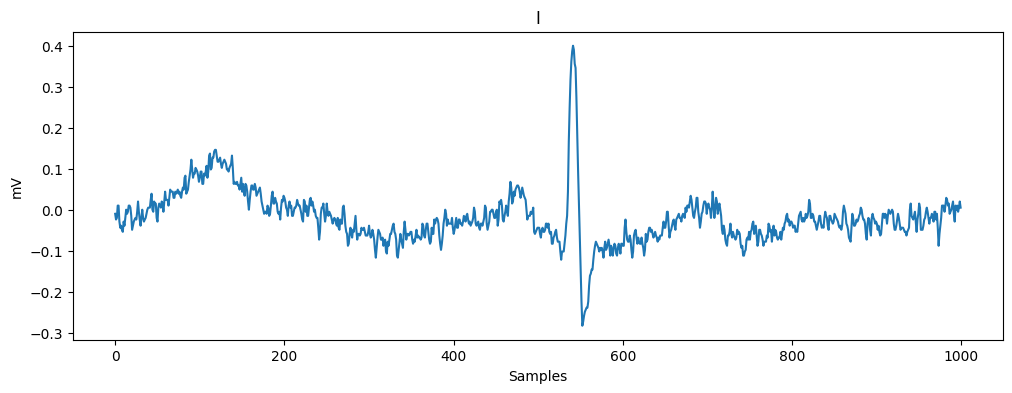

In [13]:

# Path without extension
record_path = "/content/data/JS00002"

# Read the record
record = wfdb.rdrecord(record_path)

# Signal data
signal = record.p_signal

# Metadata
print("Signal shape:", signal.shape)
print("Sampling frequency:", record.fs)
print("Signal names:", record.sig_name)
print("Units:", record.units)

# Plot first 1000 samples of first channel
plt.figure(figsize=(12,4))
plt.plot(signal[:1000, 0])
plt.title(record.sig_name[0])
plt.xlabel("Samples")
plt.ylabel(record.units[0])
plt.show()

In [14]:
print(signal)

[[-0.01   0.01   0.02  ...  0.054  0.049  0.   ]
 [-0.024 -0.02   0.005 ...  0.034  0.034 -0.015]
 [-0.02  -0.02   0.    ...  0.034  0.034 -0.01 ]
 ...
 [ 0.015  0.01  -0.005 ... -0.015 -0.02   0.005]
 [ 0.01   0.01   0.    ... -0.02  -0.024  0.   ]
 [ 0.01   0.01   0.    ... -0.024 -0.029 -0.005]]


In [29]:
len(signal[0])

12

In [16]:
import pandas as pd

data = {
    'Lead': ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'],
    'Type': ['Limb lead', 'Limb lead', 'Limb lead', 'Augmented limb', 'Augmented limb', 'Augmented limb', 'Chest lead', 'Chest lead', 'Chest lead', 'Chest lead', 'Chest lead', 'Chest lead'],
    'Views': ['Left lateral wall', 'Inferior wall', 'Inferior wall', 'Right upper side', 'High lateral wall', 'Inferior wall', 'Septal/right ventricle', 'Septal', 'Anterior', 'Anterior/apical', 'Lateral', 'Lateral']
}
df_leads = pd.DataFrame(data)

df_leads.to_csv('/content/lead_def.csv', index=False)
print("'/content/lead_def.csv' updated successfully.")


'/content/lead_def.csv' updated successfully.


# let's check frequency at Septal or wall :

In [48]:
lead =  ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [41]:
df = pd.DataFrame(signal,columns=lead)

In [42]:
df

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-0.010,0.010,0.020,0.000,-0.015,0.015,-0.010,-0.054,0.063,0.054,0.049,0.000
1,-0.024,-0.020,0.005,0.024,-0.015,-0.010,-0.020,-0.063,0.059,0.034,0.034,-0.015
2,-0.020,-0.020,0.000,0.020,-0.010,-0.010,-0.015,-0.068,0.059,0.034,0.034,-0.010
3,0.010,0.005,-0.005,-0.005,0.005,0.000,0.000,-0.054,0.073,0.059,0.059,0.010
4,0.010,0.005,-0.005,-0.005,0.005,0.000,0.005,-0.049,0.078,0.059,0.063,0.020
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.015,0.020,0.005,-0.015,0.005,0.010,0.102,-0.005,0.024,-0.005,-0.010,0.010
4996,0.015,0.015,0.000,-0.015,0.005,0.005,0.093,-0.005,0.015,-0.015,-0.020,0.005
4997,0.015,0.010,-0.005,-0.010,0.010,0.000,0.102,-0.005,0.020,-0.015,-0.020,0.005
4998,0.010,0.010,0.000,-0.010,0.005,0.005,0.098,-0.010,0.015,-0.020,-0.024,0.000
